In [0]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 148.3 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%restart_python

In [0]:
import urllib.request
import pandas as pd

# Read from /tmp where we already downloaded it
pdf = pd.read_excel("/tmp/online_retail.xlsx", engine="openpyxl")

# Clean types
pdf['InvoiceNo']   = pdf['InvoiceNo'].astype(str)
pdf['StockCode']   = pdf['StockCode'].astype(str)
pdf['Description'] = pdf['Description'].astype(str).fillna('Unknown')
pdf['CustomerID']  = pdf['CustomerID'].fillna(0).astype(int).astype(str)
pdf['Country']     = pdf['Country'].astype(str)
pdf['Quantity']    = pd.to_numeric(pdf['Quantity'],  errors='coerce').fillna(0)
pdf['UnitPrice']   = pd.to_numeric(pdf['UnitPrice'], errors='coerce').fillna(0)
pdf['InvoiceDate'] = pdf['InvoiceDate'].astype(str)

# Convert to Spark and register as temp view
df = spark.createDataFrame(pdf)
df.createOrReplaceTempView("retail")

print(f"Ready! Rows: {df.count()}, Columns: {len(df.columns)}")
df.show(5)

Ready! Rows: 541909, Columns: 8
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|2010-12-01 08:26:00|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|2010-12-01 08:26:00|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|2010-12-01 08:26:00|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|2010-12-01 08:26:00|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|2010-12-01 08:26:00|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+-------------------+---------+----------+------------

In [0]:
# Define target — customers who purchased after Oct 1 2011
rfm_target = spark.sql("""
    SELECT DISTINCT CustomerID, 1 AS purchased
    FROM retail
    WHERE CustomerID != '0'
    AND TO_DATE(InvoiceDate, 'yyyy-MM-dd HH:mm:ss') >= DATE '2011-10-01'
    AND TO_DATE(InvoiceDate, 'yyyy-MM-dd HH:mm:ss') <= DATE '2011-12-10'
""")
print(f"Customers who purchased in target period: {rfm_target.count()}")

Customers who purchased in target period: 2601


In [0]:
# Rebuild rfm with extra features for better signal
rfm_extra = spark.sql("""
    SELECT 
        CustomerID,
        DATEDIFF(DATE '2011-10-01', MAX(TO_DATE(InvoiceDate, 'yyyy-MM-dd HH:mm:ss')))  AS Recency,
        COUNT(DISTINCT InvoiceNo)                                                        AS Frequency,
        ROUND(SUM(Quantity * UnitPrice), 2)                                             AS Monetary,
        ROUND(AVG(Quantity * UnitPrice), 2)                                             AS AvgOrderValue,
        COUNT(DISTINCT TO_DATE(InvoiceDate, 'yyyy-MM-dd HH:mm:ss'))                    AS ActiveDays,
        COUNT(DISTINCT StockCode)                                                        AS UniqueProducts
    FROM retail
    WHERE CustomerID != '0'
    AND TO_DATE(InvoiceDate, 'yyyy-MM-dd HH:mm:ss') < DATE '2011-10-01'
    GROUP BY CustomerID
""")

rfm_full = rfm_extra.join(rfm_target, on='CustomerID', how='left')
rfm_full = rfm_full.fillna(0, subset=['purchased'])

rfm2 = rfm_full.toPandas()
rfm2['Target'] = rfm2['purchased'].astype(int)
rfm2 = rfm2[rfm2['Monetary'] > 0].reset_index(drop=True)

# Cap outliers
for col in ['Monetary', 'Frequency', 'AvgOrderValue', 'UniqueProducts']:
    rfm2[col] = rfm2[col].clip(upper=rfm2[col].quantile(0.99))

print(f"Shape: {rfm2.shape}")
print(rfm2[['Recency','Frequency','Monetary',
            'AvgOrderValue','ActiveDays','UniqueProducts']].describe())

Shape: (3602, 9)
           Recency    Frequency  ...   ActiveDays  UniqueProducts
count  3602.000000  3602.000000  ...  3602.000000     3602.000000
mean     90.519711     4.149639  ...     3.833426       50.459087
std      86.262461     5.155896  ...     5.527394       55.256716
min       1.000000     1.000000  ...     1.000000        1.000000
25%      17.000000     1.000000  ...     1.000000       14.000000
50%      60.000000     2.000000  ...     2.000000       31.000000
75%     145.000000     5.000000  ...     4.000000       65.750000
max     304.000000    33.000000  ...   105.000000      293.990000

[8 rows x 6 columns]


In [0]:
rfm_spark.describe(['Recency', 'Frequency', 'Monetary']).show()

+-------+-----------------+-----------------+------------------+
|summary|          Recency|        Frequency|          Monetary|
+-------+-----------------+-----------------+------------------+
|  count|             3658|             3658|              3658|
|   mean|92.36741388737015|4.352104975396392|1599.3843903772574|
| stddev|87.64219930286113|7.540910005144207| 6604.234796312138|
|    min|                1|                1|          -4287.63|
|    max|              304|              169|         202389.64|
+-------+-----------------+-----------------+------------------+



In [0]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

features = ['Recency', 'Frequency', 'Monetary',
            'AvgOrderValue', 'ActiveDays', 'UniqueProducts']

X2 = rfm2[features]
y2 = rfm2['Target']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

scaler2         = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled  = scaler2.transform(X_test2)

model2 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model2.fit(X_train2_scaled, y_train2,
           eval_set=[(X_test2_scaled, y_test2)],
           verbose=False)

y_pred2      = model2.predict(X_test2_scaled)
y_pred2_prob = model2.predict_proba(X_test2_scaled)[:, 1]

auc2 = roc_auc_score(y_test2, y_pred2_prob)
print(f"AUC-ROC: {auc2:.3f}")
print("\nClassification Report:")
print(classification_report(y_test2, y_pred2))

AUC-ROC: 0.746

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.70      0.68       346
           1       0.71      0.66      0.68       375

    accuracy                           0.68       721
   macro avg       0.68      0.68      0.68       721
weighted avg       0.68      0.68      0.68       721



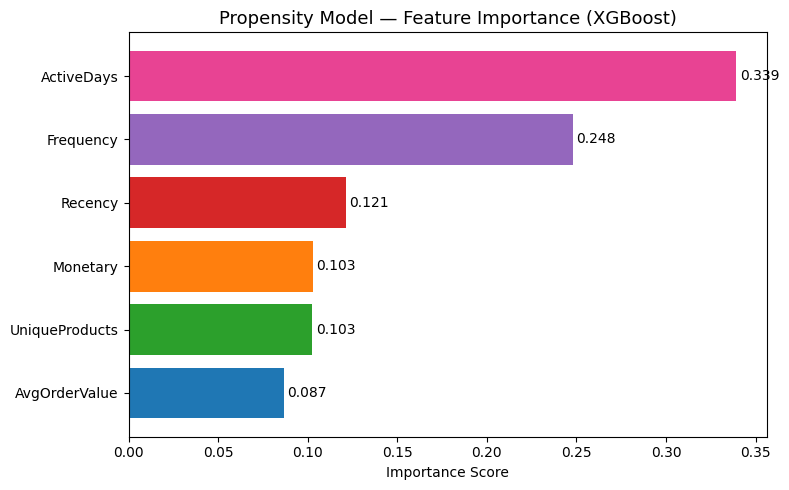

Chart saved to /tmp/feature_importance.png


In [0]:
import matplotlib.pyplot as plt

features = ['Recency', 'Frequency', 'Monetary',
            'AvgOrderValue', 'ActiveDays', 'UniqueProducts']

importances = model2.feature_importances_

# Sort by importance
sorted_idx  = importances.argsort()
sorted_feat = [features[i] for i in sorted_idx]
sorted_imp  = importances[sorted_idx]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(sorted_feat, sorted_imp,
               color=['#1f77b4','#2ca02c','#ff7f0e',
                      '#d62728','#9467bd','#e84393'])
ax.set_xlabel('Importance Score')
ax.set_title('Propensity Model — Feature Importance (XGBoost)', fontsize=13)

for bar, val in zip(bars, sorted_imp):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('/tmp/feature_importance.png', dpi=150)
plt.show()
print("Chart saved to /tmp/feature_importance.png")

In [0]:
X_full        = rfm2[features]
X_full_scaled = scaler2.transform(X_full)

rfm2['propensity_score'] = model2.predict_proba(X_full_scaled)[:, 1]

rfm2['priority_tier'] = rfm2['propensity_score'].apply(
    lambda x: 'High Priority'   if x >= 0.65 else
             ('Medium Priority'  if x >= 0.40 else
              'Low Priority')
)

print("Tier distribution:")
print(rfm2['priority_tier'].value_counts())
print()
print(rfm2[['CustomerID','propensity_score',
            'priority_tier','Monetary']].sort_values(
            'propensity_score', ascending=False).head(10))

Tier distribution:
priority_tier
Low Priority       1349
Medium Priority    1150
High Priority      1103
Name: count, dtype: int64

     CustomerID  propensity_score  priority_tier    Monetary
2599      15159          0.998029  High Priority   9537.1500
3233      12540          0.997419  High Priority  10404.7900
391       15640          0.997334  High Priority   9361.2800
2974      12621          0.997328  High Priority  11183.0400
1939      15856          0.997074  High Priority  11350.4400
1813      17581          0.997009  High Priority   8069.1400
2194      12921          0.996990  High Priority  11247.8300
1304      17675          0.996930  High Priority  14765.0795
1427      13458          0.996924  High Priority   7602.9700
2964      12681          0.996802  High Priority  10601.1700


In [0]:
output_cols  = ['CustomerID', 'Recency', 'Frequency', 'Monetary',
                'AvgOrderValue', 'propensity_score', 'priority_tier']

scored_spark = spark.createDataFrame(rfm2[output_cols])

# Register as temp view instead of Delta table
scored_spark.createOrReplaceTempView("propensity_scores")

print(f"Pipeline complete! Scored {scored_spark.count()} customers.")

Pipeline complete! Scored 3602 customers.


In [0]:
spark.sql("""
    SELECT priority_tier,
           COUNT(*)                         AS customer_count,
           ROUND(AVG(propensity_score), 3)  AS avg_score,
           ROUND(AVG(Monetary), 2)          AS avg_spend
    FROM propensity_scores
    GROUP BY priority_tier
    ORDER BY avg_score DESC
""").show()

+---------------+--------------+---------+---------+
|  priority_tier|customer_count|avg_score|avg_spend|
+---------------+--------------+---------+---------+
|  High Priority|          1103|    0.838|  2931.19|
|Medium Priority|          1150|    0.517|   734.64|
|   Low Priority|          1349|    0.265|   465.99|
+---------------+--------------+---------+---------+

